In [1]:
# imports
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import random

from scipy.stats import fisher_exact
from scipy.stats.contingency import odds_ratio

from sklearn import cluster, metrics

from scipy.stats import mannwhitneyu, false_discovery_control, ttest_ind, kstest
from matplotlib.patches import Patch

import cooler 
import cooltools
from matplotlib.colors import LogNorm
import cooltools.lib.plotting
from matplotlib.backends.backend_pdf import PdfPages

from functools import reduce 

import re
#from collections import Counter
import ast 
import scipy
%cd /home/varshini/uc_analyses/
import utils, matchmaker_functions, loops_txn
%cd /home/varshini/LoopCall_Analysis_Scripts


# plot formatting
plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams.update({'font.size': 12})

plt.rcParams["legend.frameon"] = False

/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


/home/varshini/microc_analyses/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
mindist=0
dist=100000
dist_genes = 100000
diff_thresh = 10000

In [3]:
def merged_attrs(merged_df, test_phase, control_phase):
    merged_df['triangle_fc'] = merged_df[f'triangle_score_{test_phase}'] / merged_df[f'triangle_score_{control_phase}']

    merged_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    merged_df = merged_df.sort_values(by='triangle_fc')

    return merged_df


def search_dist_for_proms(peaks_df, proms_df, dist):
    peaks_df = peaks_df.copy()
    proms_df = proms_df.copy()
    peaks_df['genes'] = [[] for _ in range(len(peaks_df))]
    peaks_df['l2fc'] = [[] for _ in range(len(peaks_df))]
    for peak_idx, peak_row in peaks_df.iterrows():
        
        peak_chr = peak_row['chr'].split('chr')[1]
        peak_coord = peak_row['coord']
        proms_df['dist'] = abs(proms_df['transcription_start_site'] - peak_coord)
        # Find genes whose TSS is within X of the peak
        nearby_genes = proms_df[
            (proms_df['chromosome_name'] == peak_chr) &
            (abs(proms_df['transcription_start_site'] - peak_coord) <= dist)
        ]

        peaks_df.at[peak_idx, 'genes'] = nearby_genes['external_gene_name'].tolist()
        peaks_df.at[peak_idx, 'min_dist'] = nearby_genes['dist'].min()
        
        if 'log2FoldChange' in proms_df.columns:
            peaks_df.at[peak_idx, 'l2fc'] = nearby_genes['log2FoldChange'].mean()
            
    peaks_df['num_genes'] = peaks_df['genes'].apply(len)
    
    return peaks_df

    
def assign_proms_to_mm(peaks_df, proms_df, min_dist, max_dist):
    peaks = peaks_df.copy()
    proms = proms_df.copy()
    
    # normalize chromosome naming
    peaks["chromosome_name"] = peaks["chr"].str.replace("chr", "", regex=False)

    # output columns
    proms["mm_quant"] = np.nan
    proms["dist"] = np.nan
    proms["triangle_fc"] = np.nan
    proms["mm_peak"] = np.nan

    for chrom, proms_sub in proms.groupby("chr"):
        peaks_sub = peaks[peaks["chr"] == chrom]
        if peaks_sub.empty:
            continue

        # sort peaks once
        peaks_sub = peaks_sub.sort_values("coord")
        peak_coords = peaks_sub["coord"].values
        peak_quants = peaks_sub["quant"].values
        tri_scores = peaks_sub["triangle_fc"].values
        # promoter coords
        prom_coords = proms_sub["transcription_start_site"].values

        # find insertion positions
        idxs = np.searchsorted(peak_coords, prom_coords)

        # clip to valid range
        idxs_left = np.clip(idxs - 1, 0, len(peak_coords) - 1)
        idxs_right = np.clip(idxs, 0, len(peak_coords) - 1)

        # compute distances to neighbors
        d_left = np.abs(prom_coords - peak_coords[idxs_left])
        d_right = np.abs(prom_coords - peak_coords[idxs_right])

        # choose nearest
        use_left = d_left <= d_right
        nearest_idxs = np.where(use_left, idxs_left, idxs_right)
        d = np.minimum(d_left, d_right)

        valid = (d <= max_dist) & (d >= min_dist)

        proms.loc[proms_sub.index[valid], "mm_quant"] = peak_quants[nearest_idxs[valid]]
        proms.loc[proms_sub.index[valid], "dist"] = d[valid]
        proms.loc[proms_sub.index[valid], "triangle_fc"] = tri_scores[nearest_idxs[valid]]
        proms.loc[proms_sub.index[valid], "mm_peak"] = peak_coords[nearest_idxs[valid]]

    return proms

In [4]:
#phases = ['new_nipbl_untreated_merged_4h', 'new_nipbl_auxin_merged_4h',
#        'SMC3_asyn_no_auxin', 'SMC3_asyn_auxin'] 

nametag = 'aboreden'
mm = f"/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/{nametag}_{dist//1000}kb_merge{diff_thresh/1000}kb_clus.bed"
mm_df = pd.read_csv(mm, sep="\t")

mm_df = merged_attrs(mm_df, test_phase='P2', control_phase='P1')
quant_range = np.sort(mm_df['quant'].unique() + 1)


In [5]:
mm_df.columns

Index(['locus', 'chr', 'coord', 'perturbation_name', 'triangle_score_P1',
       'triangle_score_P2', 'triangle_score_P3', 'triangle_score_P4', 'quant',
       'triangle_fc'],
      dtype='object')

In [6]:
pval = 0.05
pct1 = 0.1
l2fc = 0.5

In [7]:
savedir = "/mnt/md0/varshini/Analysis/Blood/figs_v3/supp14/"
if not os.path.exists(savedir):
    os.mkdir(savedir)

In [18]:
# process atac in one shot
datadir = "/mnt/md1/varshini/Blood/aboreden_hic"
all_proms = pd.read_csv(os.path.join(datadir, "promoter.stitched.bed"),
                        sep="\t",
                        names=['chr','start','end']).drop_duplicates()
all_proms['transcription_start_site'] = all_proms[['start','end']].mean(axis=1)

# process atac in one shot
degs = pd.read_csv(os.path.join(datadir, "updated_gene_expression_with_tss_windows_45min.csv")).drop_duplicates()

# nick uses -1 in the NIPBL paper, i use 0.5 here to be consistent with the other MM stuff
# but is TT-seq more noisy than RNA-Seq?
degs = degs[(degs['padj']<pval)&(degs['log2FoldChange']<-l2fc)]
degs.rename({'TSS_start':'transcription_start_site'}, inplace=True, axis=1)

In [19]:
degs

,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,chr,transcription_start_site,TSS_end
0,Pak6,524.740841,-1.130796,0.227049,-4.980411,6.344934e-07,1.013710e-04,chr2,118488812,118489812
1,Podxl,942.889957,-1.807845,0.364087,-4.965420,6.855256e-07,1.080440e-04,chr6,31513437,31514437
4,Snhg12,619.995806,-1.441575,0.293242,-4.915990,8.833511e-07,1.328670e-04,chr4,131864092,131865092
7,Ets2,1118.923812,-0.741336,0.151327,-4.898893,9.637793e-07,1.405070e-04,chr16,95923513,95924513
9,St6galnac4,583.125833,-1.056993,0.216417,-4.884060,1.039237e-06,1.484190e-04,chr2,32442097,32443097
...,...,...,...,...,...,...,...,...,...,...
11651,Myc,1624.661893,-1.303765,0.189174,-6.891903,5.505108e-12,8.025760e-09,chr15,61816395,61817395
11655,Zfp36l2,2618.507376,-0.919282,0.182711,-5.031341,4.870610e-07,8.233415e-05,chr17,84586787,84587787
11656,Exosc5,443.425797,-0.980483,0.176603,-5.551894,2.825914e-08,8.239658e-06,chr7,26443671,26444671
11660,Ergic1,1637.898582,-0.800371,0.159924,-5.004707,5.594720e-07,9.190313e-05,chr17,26697956,26698956


In [20]:
def get_odds(test_set, background_set, quant_range, test_title='P3 Marker Genes', comp_title='Background'): # first three are output from the mm finder function
    results = []
    
    for quant in quant_range:
        genes_to_mms_test = test_set[(test_set['mm_quant'].isin(quant))]
        
        
        # get the background which is not in the test set or comparison set
#         bg_not_test = pd.merge(background_set, genes_to_mms_test,
#                               left_on="ensembl_gene_id",  right_index=True, how="outer", indicator=True, suffixes=('', '_explode'))
        
#         bg_not_test = background_set[
#             ~background_set["ensembl_gene_id"].isin(
#             test_set.index
#             )]
            
        #bg_not_test = bg_not_test[bg_not_test['_merge']=='left_only']
        #bg_not_test_quant =  bg_not_test[(bg_not_test['mm_quant'].isin(quant))]
       
        # assume that all the degs are promoters 
        bg_quant = background_set[background_set['mm_quant'].isin(quant)]
        print(f"BG in quant: {len(bg_quant)}")
        degs_not_quant = len(test_set) - len(genes_to_mms_test)
        bg_not_test_quant = len(bg_quant) - len(genes_to_mms_test)
        
        
        bg_not_quant = len(background_set) - len(bg_quant) # not taking out DEGs
        
        bg_not_test_not_quant = bg_not_quant - degs_not_quant # (bg not quant) - (degs not quant)
        
        print(f"BG in quant sub test: {(bg_not_test_quant)}")
        
        print(f"Sum of BG: {bg_not_test_quant + bg_not_test_not_quant}")
        print(f"Sum of DEG: {len(genes_to_mms_test) + degs_not_quant}")
        
        tbl_test = [[len(genes_to_mms_test), bg_not_test_quant],
           [degs_not_quant, bg_not_test_not_quant]]


        print(tbl_test)
        print(fisher_exact(tbl_test))
        print(odds_ratio(tbl_test).confidence_interval(confidence_level=0.95))
        print(scipy.stats.contingency.odds_ratio(tbl_test))
        print("\n")
        
        or_res = odds_ratio(tbl_test)
        ci = or_res.confidence_interval(confidence_level=0.95)

        results.append({
            'quant': quant,
            'group': test_title,
            'OR': or_res.statistic,
            'CI_low': ci.low,
            'CI_high': ci.high
        })
            
    return results

def plot_odds(results, num_quant, test_title, bg_str):

    fig, ax = plt.subplots(figsize=(6, 4))
    results = pd.DataFrame(results)
    width = 0.75

    x = np.arange(num_quant)
    colors = {test_title:"#EE7733"}
    for offset, group in zip([-width, width], [test_title]):

        curr = results[results['group'] == group].sort_values('quant')

        y = curr['OR'].values

        yerr = np.vstack([
            y - curr['CI_low'].values,
            curr['CI_high'].values - y
        ])

        ax.bar(
            x,
            y,
            width=width,
            yerr=yerr,
            capsize=4,
            label=group,
            color=colors[group]

        )

    ax.axhline(1, ls='--', c='k')
    ax.set_xticks(x)
    ax.set_xticklabels(range(num_quant))
    ax.set_xlabel("Matchmaker Cluster (Low to High)")
    ax.set_ylabel(f"Odds Ratio over {bg_str}")
    ax.legend()
    
    return fig


In [21]:
genes_to_mms = assign_proms_to_mm(mm_df, degs, 0, dist)
genes_to_mms['ensembl_gene_id'] = genes_to_mms.index
proms_to_mms = assign_proms_to_mm(mm_df, all_proms, 0, dist)

In [22]:
proms_to_mms.groupby('mm_quant').agg('size')

mm_quant
0.0    1513
1.0    2665
2.0    1663
3.0     551
dtype: int64

In [23]:
genes_to_mms.groupby('mm_quant').agg('size')

mm_quant
0.0    52
1.0    92
2.0    61
3.0    37
dtype: int64

In [24]:
savedir

'/mnt/md0/varshini/Analysis/Blood/figs_v3/supp14/'

BG in quant: 1513
BG in quant sub test: 1461
Sum of BG: 7188
Sum of DEG: 268
[[52, 1461], [216, 5727]]
SignificanceResult(statistic=0.9436839303369078, pvalue=0.7573678786304795)
ConfidenceInterval(low=0.6795332684522931, high=1.2903678363927573)
OddsRatioResult(statistic=0.9436911495491075)


BG in quant: 2665
BG in quant sub test: 2573
Sum of BG: 7188
Sum of DEG: 268
[[92, 2573], [176, 4615]]
SignificanceResult(statistic=0.9375772886266474, pvalue=0.6499211651087854)
ConfidenceInterval(low=0.7171275686996859, high=1.2192394683129246)
OddsRatioResult(statistic=0.9375853230965284)


BG in quant: 1663
BG in quant sub test: 1602
Sum of BG: 7188
Sum of DEG: 268
[[61, 1602], [207, 5586]]
SignificanceResult(statistic=1.027538041216595, pvalue=0.8811785528632425)
ConfidenceInterval(low=0.7550870085485601, high=1.381382264284832)
OddsRatioResult(statistic=1.027534271292779)


BG in quant: 551
BG in quant sub test: 514
Sum of BG: 7188
Sum of DEG: 268
[[37, 514], [231, 6674]]
SignificanceResult

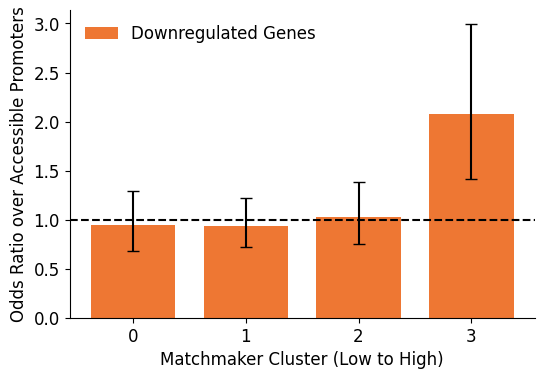

In [25]:
results = get_odds(genes_to_mms, proms_to_mms, ([0],[1], [2],[3]), 
                   test_title='Downregulated Genes',)

fig = plot_odds(results, 4, 'Downregulated Genes', 'Accessible Promoters')
#plt.savefig(os.path.join(savedir, "or_no_replacement_aboreden.svg"))
plt.show()

In [40]:
proms_to_mms

,chr,start,end,transcription_start_site,mm_quant,dist,triangle_fc,mm_peak
0,chr1,4773758,4777458,4775608.0,NaN,NaN,NaN,NaN
1,chr1,4797055,4799040,4798047.5,NaN,NaN,NaN,NaN
2,chr1,4846504,4849247,4847875.5,0.0,57995.0,0.853890,4905870.5
3,chr1,5072582,5074332,5073457.0,NaN,NaN,NaN,NaN
4,chr1,6203372,6205942,6204657.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
7451,chrX,162916294,162918467,162917380.5,0.0,34655.5,0.582721,162952036.0
7452,chrX,162946969,162949665,162948317.0,0.0,3719.0,0.582721,162952036.0
7453,chrX,163819015,163821486,163820250.5,NaN,NaN,NaN,NaN
7454,chrX,165111898,165112865,165112381.5,NaN,NaN,NaN,NaN
